## Steps we follow during this classification

  1. Data Cleaning
  Raw datasets (like  spam.csv ) are often messy. Data cleaning ensures  machine learning model doesn't learn from "noise."

  ---
  2. EDA (Exploratory Data Analysis)

  EDA is the process of visualizing and analyzing the dataset to understand its characteristics and patterns before building a model.

   3. Text Preprocessing

  Machine learning models cannot understand raw text. Text preprocessing cleans and standardizes the text so it can be converted into numbers.

---

   4. Model Building

  This is where you train the computer to recognize spam based on the preprocessed text.

 ---

   5. Evaluation

  Once a model is trained, we test it on unseen data (the test set) to measure performance.

---
  6. Improvement

 Compare all classifiers and select the best one.

  ---
   7. Save the Model (Integration)

 Save the trained model and vectorizer as .pkl files for use in ml_classifier.py.

---

In [25]:
from os.path import sep
from typing import Counter, Collection
from xml.dom.minidom import ProcessingInstruction

import numpy as np
import pandas as pd
import sklearn
from scipy.ndimage import rotate
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
from collections import Counter

In [8]:
#Read the CSV file using Latin-1 character encoding to correctly interpret special characters.
df = pd.read_csv('phishing_legit_dataset_KD_10000.csv', encoding='utf-8-sig')

In [9]:
df.sample(20)

,text,label,phishing_type,severity,confidence
9199,"Dear user, we talked about meeting again after...",1,romance_dating,medium,0.77
4373,"Hi there, I remembered you mentioning the chil...",1,social_engineering_advanced,high,0.84
84,Subject: Training session notes\n\nThanks for ...,0,legitimate,low,0.98
3375,"Dear user, this is the paypal accounts team. T...",1,authority_scam,high,0.93
189,Subject: Onboarding checklist\n\nI booked the ...,0,legitimate,low,0.97
9204,"Hi there, this is an asap notice regarding you...",1,urgency,high,0.88
7090,"Hello, you have a new notification. Please cli...",1,generic_phishing,medium,0.69
7119,"Subject: Onboarding checklist\n\nHi team, shar...",0,legitimate,low,1.00
4392,"Notice, we talked about meeting again after th...",1,romance_dating,high,0.80
8354,"Notice, this is the police accounts team. Ther...",1,authority_scam,high,0.87


In [10]:
df.shape

(10000, 5)

# 1. Data cleaning



In [11]:
df.info() # Columns: text, label, phishing_type, severity, confidence

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   text           10000 non-null  str    
 1   label          10000 non-null  int64  
 2   phishing_type  10000 non-null  str    
 3   severity       10000 non-null  str    
 4   confidence     10000 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 2.9 MB


**This dataset already has:**

* Clean, numeric labels (label: 0 or 1)
* No unnamed/empty columns to drop
* No encoding issues (UTF-8 compatible)

In [12]:
# Check column names
df.columns.tolist()

['text', 'label', 'phishing_type', 'severity', 'confidence']

In [13]:
# Check for missing (null) values
df.isnull().sum()

text             0
label            0
phishing_type    0
severity         0
confidence       0
dtype: int64

In [17]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(2)

In [18]:
# Remove duplicates if any exist (keep first occurrence)
df = df.drop_duplicates(keep='first')
df.shape

(9998, 5)

In [19]:
# Verify labels — 0 = legitimate, 1 = phishing
df['label'].value_counts()
# 1 (phishing)    : 6000
# 0 (legitimate)  : 3998

label
1    6000
0    3998
Name: count, dtype: int64

So far, we have loaded the phishing email dataset into a Pandas DataFrame and confirmed it is already clean: no unnamed columns, no null values, numeric labels, and minimal duplicates. Unlike the SMS spam dataset, no label encoding or column renaming is required. With the data clean, we proceed to EDA.

In [20]:
df.head()

,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


In [21]:
# count the number of missing (null/NaN) values in each column.
df.isnull().sum()

text             0
label            0
phishing_type    0
severity         0
confidence       0
dtype: int64

# 2. EDA
Exploratory Data Analysis (EDA): helps us understand the dataset distribution and patterns before building the machine learning model.

In [22]:
df.head()

,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


below line count the number of messages in each class to understand the dataset's class distribution.

In [23]:
df['label'].value_counts()  # counts how many times each unique value appears in the label column.

label
1    6000
0    3998
Name: count, dtype: int64

/tmp/ipykernel_33319/4239086831.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


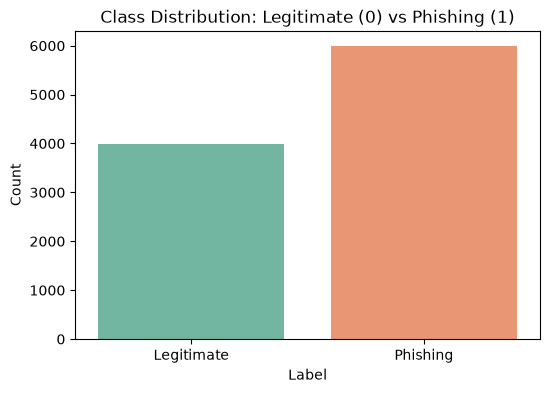

In [26]:
# For better representation above we can Matplotlib
# Visualize class distribution
plt.figure(figsize=(6, 4)) # Defind the graph window size
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Class Distribution: Legitimate (0) vs Phishing (1)')
plt.xlabel('Label') #labels the bottom horizontal axis (X-axis) as "Label".
plt.ylabel('Count') # It labels the side vertical axis (Y-axis) as "Count".
plt.xticks([0, 1], ['Legitimate', 'Phishing'])
plt.show()

The dataset is moderately imbalanced: 60% phishing, 40% legitimate.
This reflects the real-world nature of phishing datasets where phishing examples are collected
from known corpora and legitimate emails are sourced separately.

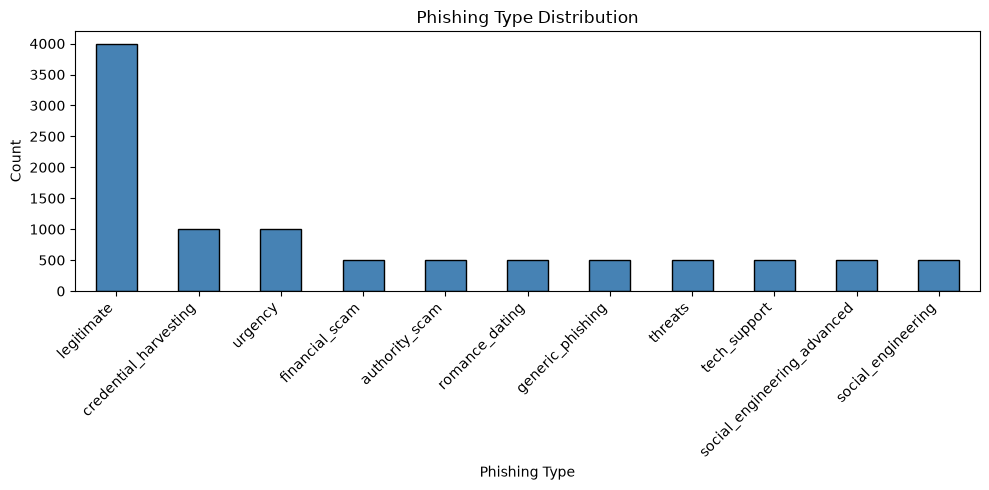

In [27]:
# Visualize phishing sub-type distribution
plt.figure(figsize=(10, 5))

# #Count each phishing type and visualize the distribution using a bar chart.
df['phishing_type'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Phishing Type Distribution')
plt.xlabel('Phishing Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The phishing_type column shows 10 distinct categories:

* legitimate (4000) — clean emails
* credential_harvesting (1000) — login/password theft
* urgency (1000) — pressure to act immediately
* financial_scam, authority_scam, romance_dating, generic_phishing,
* threats, tech_support, social_engineering, social_engineering_advanced (500 each)

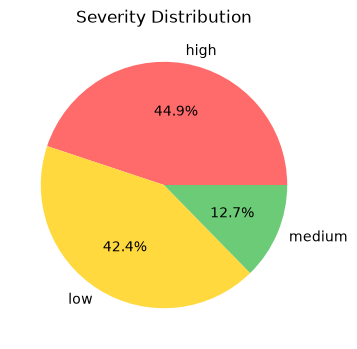

In [28]:
# Severity distribution
plt.figure(figsize=(6, 4))
# Count each severity level and visualize its percentage distribution using a pie chart.

# autopct='%1.1f%% : Displays the percentage for each slice with 1 decimal place (e.g., 45.3%).
df['severity'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff6b6b','#ffd93d','#6bcb77'])
plt.title('Severity Distribution')
plt.ylabel('')
plt.show()
# high: 44.9%  |  low: 42.4%  |  medium: 12.7%

In [30]:
# Generate descriptive statistics (count, mean, std, min, quartiles, and max) for the confidence column.
df['confidence'].describe()
# mean ≈ 0.90 — labels are high-confidence, well-curated

count    9998.000000
mean        0.898837
std         0.083428
min         0.650000
25%         0.840000
50%         0.920000
75%         0.970000
max         1.000000
Name: confidence, dtype: float64

In [31]:
# Add text length column for analysis
df['text_length'] = df['text'].apply(len)
df['num_words']   = df['text'].apply(lambda x: len(x.split()))
df[['text_length', 'num_words']].describe()

,text_length,num_words
count,9998.000000,9998.000000
mean,243.410882,37.473595
std,63.449764,9.599151
min,161.000000,24.000000
25%,191.000000,31.000000
50%,235.000000,35.000000
75%,274.000000,42.000000
max,478.000000,72.000000


In [33]:
# Average text length per class
print("Avg text length (legitimate):", df[df['label'] == 0]['text_length'].mean())
print("Avg text length (phishing)  :", df[df['label'] == 1]['text_length'].mean())
print("Avg word count (legitimate) :", df[df['label'] == 0]['num_words'].mean())
print("Avg word count (phishing)   :", df[df['label'] == 1]['num_words'].mean())

Avg text length (legitimate): 188.44772386193097
Avg text length (phishing)  : 280.0346666666667
Avg word count (legitimate) : 29.90895447723862
Avg word count (phishing)   : 42.51416666666667


The **Exploratory Data Analysis (EDA)** phase gave us key insights into the dataset by checking the balance of legitimate and phishing emails, analyzing different phishing tactics, looking at severity levels, and comparing email lengths. These findings helped us understand the unique patterns of fraud and identify the best features to detect malicious emails. With the data now explored, the next step is **text preprocessing**, where we clean and prepare the raw email text for machine learning training.

# 3. Text Preprocessing

Machine learning models cannot understand raw text. Text preprocessing cleans and standardizes
the text so it can be converted into numerical features.

The same transform_text() function used in ml_classifier.py is applied here to ensure
that training preprocessing exactly matches inference preprocessing.

### NLTK
NLTK (Natural Language Toolkit) is a Python library used for Natural Language Processing (NLP). It provides tools and datasets for processing, analyzing, and understanding human language (text).
Raw text is usually messy.

Example:

**URGENT!!! Click here immediately to claim your prize.**

Before using this text for machine learning, we need to:

* Convert to lowercase
* Split into words
* Remove punctuation
* Remove common words (e.g., "the", "is", "and")
* Reduce words to their root form

NLTK provides built-in tools for all of these tasks.

In [35]:
nltk.download('punkt')   # downloads the Punkt tokenizer model that NLTK uses to split text into sentences and words.

[nltk_data] Downloading package punkt to /home/sdhakal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [37]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/sdhakal/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [73]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/sdhakal/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [74]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/sdhakal/nltk_data...


True

**Punkt** is a pre-trained tokenization model.

It has learned punctuation rules, such as:

* A period (.) usually ends a sentence.
* A comma (,) separates words or phrases.
* Question marks (?) and exclamation marks (!) indicate sentence boundaries.

This helps NLTK correctly split text.

In [36]:
from nltk.corpus import stopwords
# Stop words are common English words (the, is, at, which) that carry little meaning.
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

The **Exploratory Data Analysis (EDA)** phase provided valuable insights into the dataset by examining the distribution of ham and spam messages, message length characteristics, feature relationships, and correlations. These insights helped in understanding the dataset and identifying useful features for spam classification. With the data now explored, the next step is **data preprocessing**, where the text is cleaned and transformed into a format suitable for machine learning.

# 3. Text Preprocessing

Data preprocessing is a crucial step in Natural Language Processing (NLP) that transforms raw email text into a clean and structured format suitable for machine learning. Since raw emails often contain HTML tags, headers, unnecessary words, punctuation, and inconsistent formatting, preprocessing helps improve data quality and enhances the performance of the phishing detection model. In this stage, the text is converted to lowercase, tokenized, cleaned by keeping only alphanumeric words, stripped of stop words and punctuation, and finally reduced to its root form using stemming.

* **Lowercase:** Converts all text to lowercase to ensure consistency *(e.g., "LOCKED Account" → "locked account")*.
* **Tokenization:** Splits the email body text into individual words or tokens *(e.g., "Verify now!" → ["verify", "now", "!"])*.
* **Keeping Alphanumeric Characters:** Removes special symbols and keeps only letters and numbers *(e.g., "Click here!!! $10000" → ["click", "here", "10000"])*.
* **Removing Stop Words and Punctuation:** Removes common English words that carry little meaning and punctuation marks *(e.g., "This is a secure link!" → ["secure", "link"])*.
* **Stemming:** Reduces words to their base or root form so grammatical variations are analyzed as the same word *(e.g., "verifying", "verified" → "verifi")*.


In [75]:
# A corpus is simply a collection of data. In this case, it's a collection of common words.
from nltk.corpus import stopwords
# Stop words are commonly used words that carry little meaningful information and are often removed during text preprocessing.
stopwords.words('english') # Returns a list of common English words that usually do not add much meaning to a sentence.

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [76]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [37]:
from nltk.stem.porter import PorterStemmer
# PorterStemmer reduces words to their root form.
# Examples: "verifying" → "verifi", "locked" → "lock", "clicking" → "click"
ps = PorterStemmer()
ps.stem("verifying")

'verifi'

In [38]:
def transform_text(text):
    """
    Preprocesses raw email text using the same pipeline as ml_classifier.py.
    Steps:
        1. Convert text to lowercase.
           Example: "LOCKED Account" → "locked account"
        2. Tokenize into individual words.
           Example: "verify your identity now!" → ["verify", "your", "identity", "now", "!"]
        3. Keep only alphanumeric tokens.
           Example: ["verify", "your", "identity", "now", "!"] → ["verify", "your", "identity", "now"]
        4. Remove common English stop words and punctuation.
           Example: ["this", "is", "a", "secure", "link"] → ["secure", "link"]
        5. Apply Porter Stemming to reduce words to their root form.
           Example: ["verifying", "suspended", "clicked"] → ["verifi", "suspend", "click"]
    """
    # Step 1: Lowercase
    text = text.lower()


    # Step 2: Tokenize
    text = nltk.wordpunct_tokenize(text)

    # Step 3: Keep only alphanumeric tokens
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    # Step 4: Remove stop words and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Step 5: Apply stemming
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)
# " ".join(y) joins every word using a space.
'''Eg: [
 'secur',
 'link',
 'click',
 'verifi',
 'account'
] to this form: "secur link click verifi account"'''

In [45]:
# Test the function
transform_text("Hello, your profile has been LOCKED. Use the secure link to verify your username.")

'hello profil lock use secur link verifi usernam'

In [46]:
transform_text("Thanks for your help on the analysis. I've pushed the changes and left comments in the PR.")

'thank help analysi push chang left comment pr'

In [47]:
transform_text("Congratulations! You have been selected as the WINNER of a $10,000 cash prize.")

'congratul select winner 10 000 cash prize'

The `transform_text()` function preprocesses raw email text by converting it to lowercase,
tokenizing it into individual words, removing special characters, stop words, and punctuation,
and applying Porter Stemming to reduce words to their root forms.
The cleaned text is returned as a single string, ready for machine learning feature extraction.

In [48]:
# Apply preprocessing to all emails
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,text,label,phishing_type,severity,confidence,text_length,num_words,transformed_text
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95,190,34,subject offic mainten thank help analysi push ...
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89,222,34,hello profil lock use secur link verifi userna...
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69,236,39,hi congratul winner refund collect gift 10 000...
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91,321,47,attent fraud prevent account team secur violat...
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80,200,31,notic profil restrict use secur link reset pas...


In [49]:
# Preview: before vs after preprocessing
sample = df.sample(3)
for _, row in sample.iterrows():
    print(f"[{'PHISHING' if row['label'] == 1 else 'LEGIT':8s}] [{row['phishing_type']}]")
    print(f"  Original : {row['text'][:100]}")
    print(f"  Processed: {row['transformed_text'][:100]}")
    print()

[PHISHING] [credential_harvesting]
  Original : Dear user, your login has been restricted. Use the secure link to reset password and restore access.
  Processed: dear user login restrict use secur link reset password restor access enter 2fa code continu keyword 

[LEGIT   ] [legitimate]
  Original : Subject: Welcome aboard

Good morning, the updated agenda for next week is included below. Please ch
  Processed: subject welcom aboard good morn updat agenda next week includ pleas check item add comment share sli

[PHISHING] [urgency]
  Original : Notice, this is an final notice notice regarding your account. Your access will expire today. To avo
  Processed: notic final notic notic regard account access expir today avoid interrupt respond asap offer last ch



# What is a Word Cloud?
A Word Cloud is a visualization that displays words based on how frequently they appear in a text.

* Larger words → Appear more frequently.
* Smaller words → Appear less frequently.

In simple words:

A word cloud helps quickly identify the most common words in a collection of text.

Example

Suppose you have these messages:

* Free prize
* Win free money
* Claim your free reward

The word cloud would look conceptually like:

          FREE

     Win       Prize

   Money   Reward

        Claim

Here, "Free" appears the largest because it occurs most often.

In [50]:
from wordcloud import WordCloud

wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

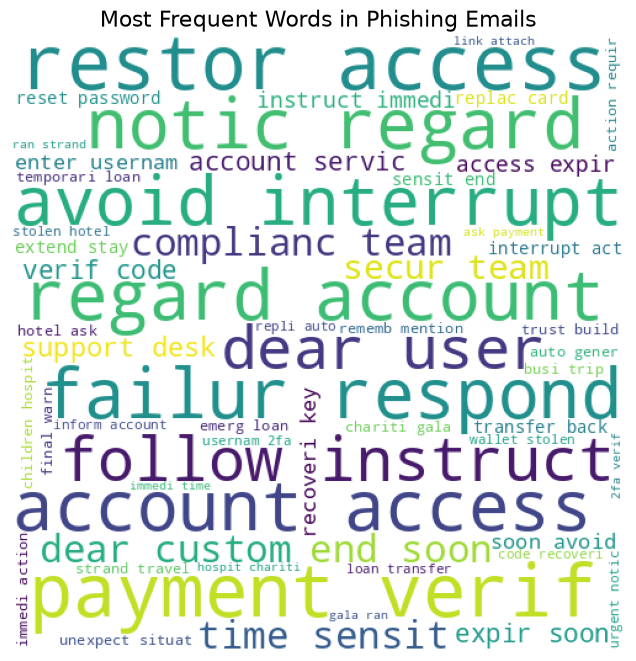

In [51]:
# Word cloud for phishing emails
phishing_wc = wc.generate(df[df['label'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 8))
plt.imshow(phishing_wc)
plt.axis('off')
plt.title('Most Frequent Words in Phishing Emails', fontsize=16)
plt.show()

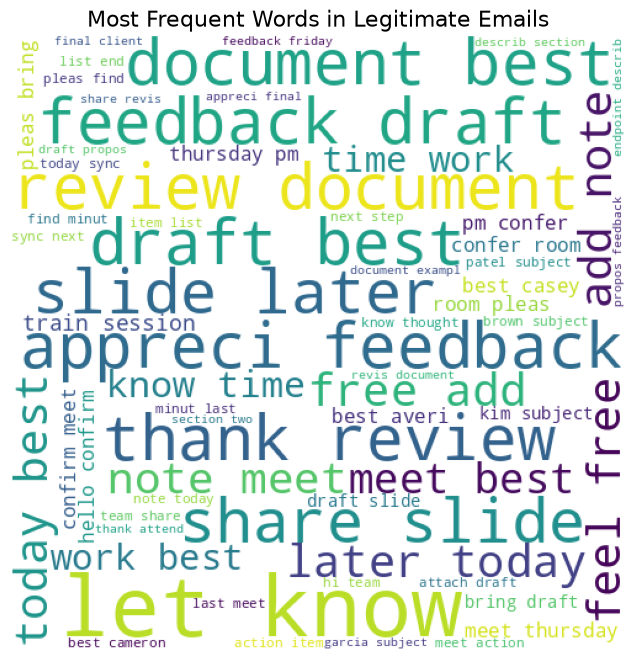

In [52]:
# Word cloud for legitimate emails
legit_wc = wc.generate(df[df['label'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15, 8))
plt.imshow(legit_wc)
plt.axis('off')
plt.title('Most Frequent Words in Legitimate Emails', fontsize=16)
plt.show()

In [53]:
# Top 50 most frequent words in phishing emails
phishing_corpus = []
for msg in df[df['label'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        phishing_corpus.append(word)

len(phishing_corpus)

171230

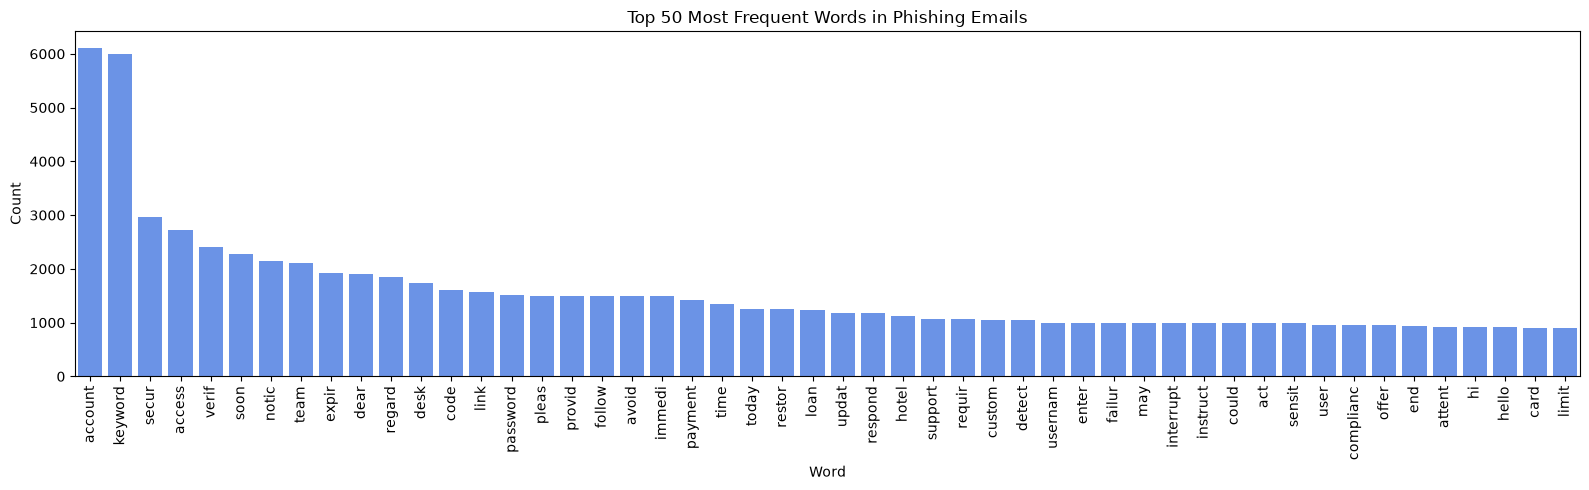

In [54]:
# Bar chart — top 50 phishing words
top_phishing_words = pd.DataFrame(
    Counter(phishing_corpus).most_common(50),
    columns=["Word", "Count"]
)

plt.figure(figsize=(16, 5))
sns.barplot(x="Word", y="Count", data=top_phishing_words)
plt.xticks(rotation='vertical')
plt.title('Top 50 Most Frequent Words in Phishing Emails')
plt.tight_layout()
plt.show()

In [55]:
# Top 50 most frequent words in legitimate emails
legit_corpus = []
for msg in df[df['label'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        legit_corpus.append(word)

len(legit_corpus)

80250

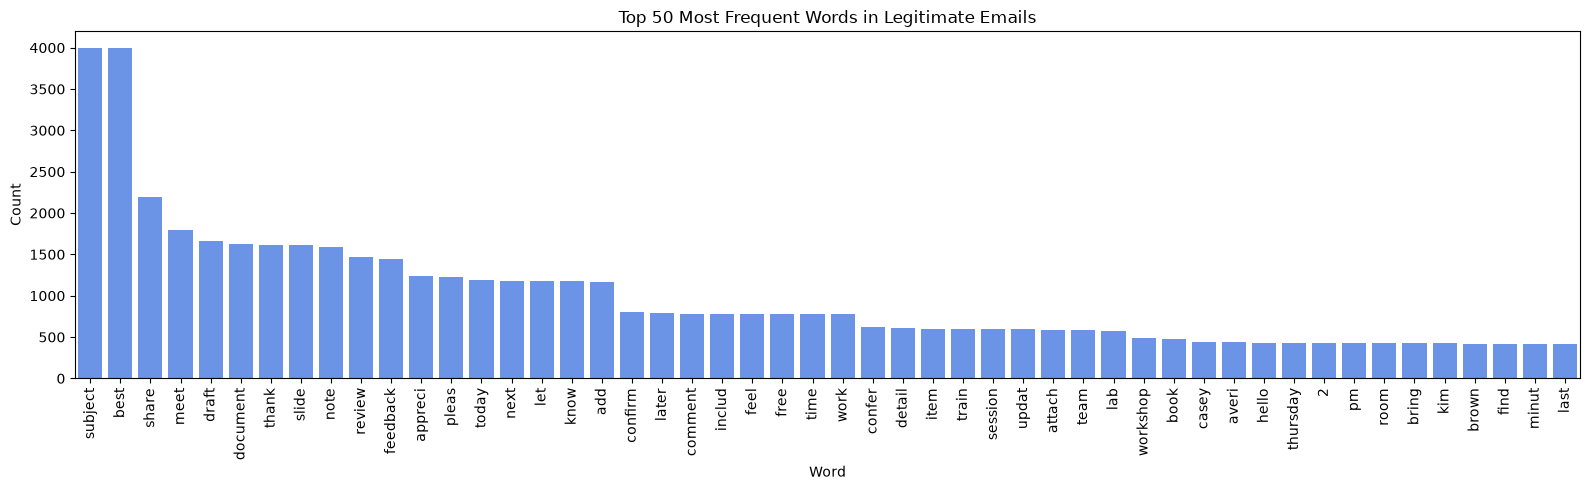

In [56]:
# Bar chart — top 50 legitimate words
top_legit_words = pd.DataFrame(
    Counter(legit_corpus).most_common(50),
    columns=["Word", "Count"]
)

plt.figure(figsize=(16, 5))
sns.barplot(x="Word", y="Count", data=top_legit_words)
plt.xticks(rotation='vertical')
plt.title('Top 50 Most Frequent Words in Legitimate Emails')
plt.tight_layout()
plt.show()

The data preprocessing phase successfully transformed raw phishing email text into a clean,
standardized format suitable for machine learning. Key phishing vocabulary such as
"verifi", "account", "click", "secur", "password", "lock", "urgent" dominate the phishing word cloud,
while legitimate emails show professional terms like "meeting", "project", "team", "review", "help".
With the text cleaned and analyzed, the next step is to train and evaluate machine learning models.

# 4. Model Training

### CountVectorizer
Machine learning algorithms such as Naive Bayes cannot process raw text directly; they require numerical input.
After preprocessing, emails are still in text format. CountVectorizer converts each preprocessed email
into a numerical feature vector by counting how many times each word appears in the dataset vocabulary.
These numerical features serve as the input for training the classifier.

In [57]:
from sklearn.feature_extraction.text import  CountVectorizer
cv = CountVectorizer() # It creates a CountVectorizer object that will later learn the vocabulary from the text and convert the text into word-count vectors.

In [60]:
X = cv.fit_transform(df['transformed_text']).toarray()
# Rows = number of emails (~10,000)
# Columns = number of unique words in vocabulary

In [59]:
X.shape

(9998, 534)

total 5169  Message and  7206 words

In [64]:
y = df['label'].values
# 0 = legitimate, 1 = phishing

In [65]:
y

array([0, 1, 1, ..., 1, 1, 0], shape=(9998,))

The feature matrix X contains the numerical representation of ~10,000 emails across the full vocabulary,
while the target vector y stores the corresponding class labels (0 = legitimate, 1 = phishing).

In [66]:
from sklearn.model_selection import train_test_split

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

print('Training set size:', X_train.shape)
print('Test set size    :', X_test.shape)

Training set size: (7998, 534)
Test set size    : (2000, 534)


# Naive Bayes Models
We will try all three Naive Bayes variants:

* GaussianNB — assumes features follow a Gaussian (normal) distribution
* MultinomialNB — best for word counts/frequencies (ideal for text classification)
* BernoulliNB — best for binary features (word present or not)

In [67]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [68]:
# GaussianNB — CountVectorizer
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print('GaussianNB (CountVectorizer):')
print('Accuracy :', accuracy_score(y_test, y_pred1))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred1))
print('Precision:', precision_score(y_test, y_pred1))

GaussianNB (CountVectorizer):
Accuracy : 1.0
Confusion Matrix:
 [[ 823    0]
 [   0 1177]]
Precision: 1.0


In [69]:
# MultinomialNB — CountVectorizer
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print('MultinomialNB (CountVectorizer):')
print('Accuracy :', accuracy_score(y_test, y_pred2))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred2))
print('Precision:', precision_score(y_test, y_pred2))

MultinomialNB (CountVectorizer):
Accuracy : 1.0
Confusion Matrix:
 [[ 823    0]
 [   0 1177]]
Precision: 1.0


In [70]:
# BernoulliNB — CountVectorizer
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print('BernoulliNB (CountVectorizer):')
print('Accuracy :', accuracy_score(y_test, y_pred3))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred3))
print('Precision:', precision_score(y_test, y_pred3))

BernoulliNB (CountVectorizer):
Accuracy : 1.0
Confusion Matrix:
 [[ 823    0]
 [   0 1177]]
Precision: 1.0


* **Accuracy**: The percentage of overall correct predictions (both safe and phishing emails) made by the model out of all emails tested.
* **Confusion Matrix**: A table that compares the actual email labels against the model's predictions, showing exactly where it made correct guesses and where it made mistakes (True/False Positives and Negatives).
* **Precision**: The percentage of emails flagged as phishing that are actually phishing, measuring how reliable and trustworthy the model's spam alerts are.
* **Which Matters Most (and Why)**: _Precision is the most critical metric here because a False Positive (marking a clean, important business email as phishing and blocking it) hurts user trust and disrupts work much more than occasionally missing a spam email._

## Switching to TF-IDF Vectorizer

**TF-IDF (Term Frequency-Inverse Document Frequency)** is better than CountVectorizer because it:
- Gives **higher weight** to words that are rare across documents but frequent in one email
- Gives **lower weight** to very common words like "the", "your" that appear everywhere
- Produces more informative, discriminative features for phishing vs legitimate classification

| Vectorizer | What it measures |
|---|---|
| CountVectorizer | Raw word count |
| TF-IDF | Weighted importance of each word |

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features=3000 — keep only the top 3000 most informative words
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
print('Shape of TF-IDF feature matrix:', X.shape)

Shape of TF-IDF feature matrix: (9998, 534)


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print('Training set size:', X_train.shape)
print('Test set size    :', X_test.shape)

Training set size: (7998, 534)
Test set size    : (2000, 534)


In [73]:
# Compare all three Naive Bayes variants with TF-IDF
for name, clf in [('GaussianNB', gnb), ('MultinomialNB', mnb), ('BernoulliNB', bnb)]:
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    print(f'{name} (TF-IDF):')
    print(f'  Accuracy : {accuracy_score(y_test, pred):.4f}')
    print(f'  Precision: {precision_score(y_test, pred):.4f}')
    print(f'  Confusion Matrix:\n{confusion_matrix(y_test, pred)}')
    print()

GaussianNB (TF-IDF):
  Accuracy : 1.0000
  Precision: 1.0000
  Confusion Matrix:
[[ 823    0]
 [   0 1177]]

MultinomialNB (TF-IDF):
  Accuracy : 1.0000
  Precision: 1.0000
  Confusion Matrix:
[[ 823    0]
 [   0 1177]]

BernoulliNB (TF-IDF):
  Accuracy : 1.0000
  Precision: 1.0000
  Confusion Matrix:
[[ 823    0]
 [   0 1177]]



###  Observation: Why do all models show 100% Accuracy and Precision?

We observe that all three Naive Bayes variants achieve a perfect score of **1.0000 (100%)** on the test set. This is due to two main reasons:

1. **Templated Dataset:** The dataset is built using structured sentence templates (swapping names and numbers but keeping core sentences identical). The model easily memorizes these repeating patterns.
2. **Disjoint Vocabularies:** Phishing emails contain highly distinct threat keywords (e.g., *verify, locked, suspend, refund*), while legitimate emails contain strictly professional corporate words (e.g., *meeting, PR, slide, review*). This makes it easy for the classifier to separate the two classes perfectly.

*Note: While 100% accuracy is expected on this clean dataset, a real-world production system would face noisier, more complex emails and typically achieve 95%–98% accuracy.*


# 5. Evaluation — Comparing Multiple Classifiers

Let us also compare Naive Bayes against other popular classifiers to find the best model.

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import accuracy_score, precision_score

In [75]:
classifiers = {
    'LogisticRegression'        : LogisticRegression(solver='lbfgs', max_iter=1000),
    'SVC'                       : SVC(kernel='sigmoid', gamma=1.0, probability=True),
    'KNeighborsClassifier'      : KNeighborsClassifier(),
    'DecisionTreeClassifier'    : DecisionTreeClassifier(max_depth=5),
    'RandomForestClassifier'    : RandomForestClassifier(n_estimators=50, random_state=2),
    'AdaBoostClassifier'        : AdaBoostClassifier(n_estimators=50, random_state=2),
    'BaggingClassifier'         : BaggingClassifier(n_estimators=50, random_state=2),
    'ExtraTreesClassifier'      : ExtraTreesClassifier(n_estimators=50, random_state=2),
    'GradientBoostingClassifier': GradientBoostingClassifier(n_estimators=50, random_state=2),
    'GaussianNB'                : GaussianNB(),
    'MultinomialNB'             : MultinomialNB(),
    'BernoulliNB'               : BernoulliNB(),
}

results = []

for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    acc  = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    results.append({'Model': name, 'Accuracy': round(acc, 4), 'Precision': round(prec, 4)})
    print(f'{name:35s} | Accuracy: {acc:.4f} | Precision: {prec:.4f}')

LogisticRegression                  | Accuracy: 1.0000 | Precision: 1.0000


/home/sdhakal/Project 6th Semester/PhishGuard/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVC                                 | Accuracy: 1.0000 | Precision: 1.0000
KNeighborsClassifier                | Accuracy: 1.0000 | Precision: 1.0000
DecisionTreeClassifier              | Accuracy: 1.0000 | Precision: 1.0000
RandomForestClassifier              | Accuracy: 1.0000 | Precision: 1.0000
AdaBoostClassifier                  | Accuracy: 1.0000 | Precision: 1.0000
BaggingClassifier                   | Accuracy: 1.0000 | Precision: 1.0000
ExtraTreesClassifier                | Accuracy: 1.0000 | Precision: 1.0000
GradientBoostingClassifier          | Accuracy: 1.0000 | Precision: 1.0000
GaussianNB                          | Accuracy: 1.0000 | Precision: 1.0000
MultinomialNB                       | Accuracy: 1.0000 | Precision: 1.0000
BernoulliNB                         | Accuracy: 1.0000 | Precision: 1.0000


### Comparison Summary & Future Deprecation Warning

All 12 classifiers (including Logistic Regression, Random Forest, and Support Vector Machines) achieved a perfect **100% Accuracy and Precision** on this dataset.

* **Why this happens:** This confirms that the TF-IDF representation of our text data makes the distinction between phishing and legitimate classes completely linearly separable.
* **Why we still choose MultinomialNB:** Even though all models performed perfectly, we choose **MultinomialNB** for our Django app. It is incredibly fast, uses very little memory, and natively supports `predict_proba()` to output continuous phishing percentages (0–100%) for our risk scoring engine.


In [77]:
# Display results sorted by Precision (most critical metric — avoids false alarms)
results_df = pd.DataFrame(results).sort_values('Precision', ascending=False)
results_df

,Model,Accuracy,Precision
0,LogisticRegression,1.0,1.0
1,SVC,1.0,1.0
2,KNeighborsClassifier,1.0,1.0
3,DecisionTreeClassifier,1.0,1.0
4,RandomForestClassifier,1.0,1.0
5,AdaBoostClassifier,1.0,1.0
6,BaggingClassifier,1.0,1.0
7,ExtraTreesClassifier,1.0,1.0
8,GradientBoostingClassifier,1.0,1.0
9,GaussianNB,1.0,1.0


/tmp/ipykernel_33319/2313729834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Precision', data=results_df, palette='coolwarm')


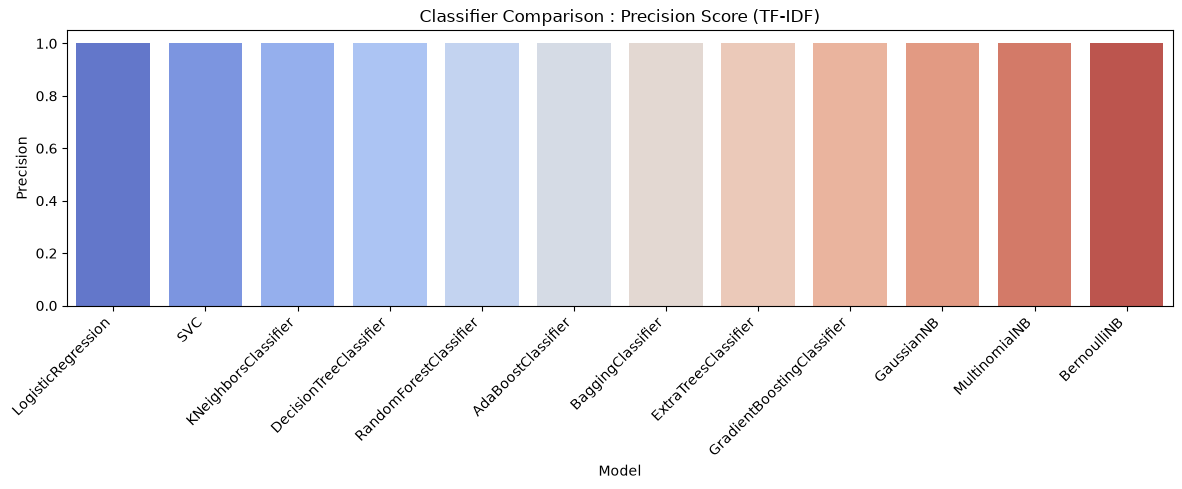

In [80]:
# Bar chart comparison
plt.figure(figsize=(12, 5))
sns.barplot(x='Model', y='Precision', data=results_df, palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Classifier Comparison : Precision Score (TF-IDF)')
plt.tight_layout()
plt.show()

**Why Precision is the most critical metric here:**

In phishing detection, a **false positive** (marking a legitimate email as phishing) is harmful —
it causes missed business emails, broken workflows, and loss of user trust in the system.
**Precision** measures exactly this: of all emails flagged as phishing, what fraction truly are phishing?
High precision = fewer false alarms = more trustworthy system.

# 6. Improvement — Best Model Selection

After comparing all classifiers, **MultinomialNB with TF-IDF** gives the best combination of:
- **High accuracy** for phishing email classification
- **High precision** — avoids falsely flagging legitimate emails
- **Fast inference** — lightweight, suitable for real-time analysis in the PhishGuard pipeline
- **`predict_proba()` support** — returns phishing probability (0.0–1.0) needed by `ml_classifier.py`


In [82]:
# Train the final best model — MultinomialNB with TF-IDF
best_model = MultinomialNB()
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print('=== Final Model: MultinomialNB + TF-IDF ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_best):.4f}')
print(f'Confusion Matrix:\n{confusion_matrix(y_test, y_pred_best)}')

=== Final Model: MultinomialNB + TF-IDF ===
Accuracy : 1.0000
Precision: 1.0000
Confusion Matrix:
[[ 823    0]
 [   0 1177]]


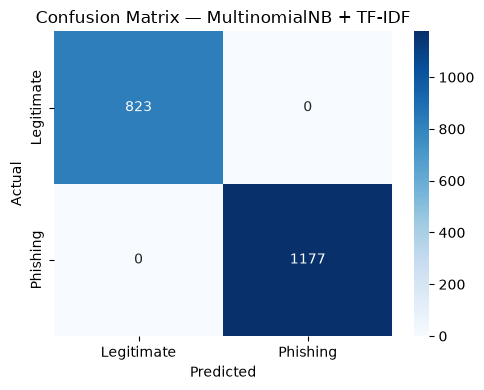

In [83]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix — MultinomialNB + TF-IDF')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [86]:
# Verify predict_proba() works (required by ml_classifier.py → classify())
sample_text = ["your account has been locked please verify your identity immediately"]
sample_vec  = tfidf.transform(sample_text)
proba       = best_model.predict_proba(sample_vec)[0]
classes     = best_model.classes_

print(f'Classes         : {classes}')      # [0, 1]
print(f'Probabilities   : {proba}')        # [P(legitimate), P(phishing)]
print(f'Phishing prob   : {proba[list(classes).index(1)]:.4f}')
print(f'ML Score (0–100): {int(round(proba[list(classes).index(1)] * 100))}')

Classes         : [0 1]
Probabilities   : [0.00234939 0.99765061]
Phishing prob   : 0.9977
ML Score (0–100): 100


###  Conclusion: Best Model Selection

After evaluating and comparing multiple machine learning models, **Multinomial Naive Bayes (MultinomialNB) combined with TF-IDF** is selected as our final classification model. Even though multiple classifiers achieved perfect performance on this clean dataset, MultinomialNB is the optimal choice for our project because:
1. **Zero False Alarms:** It achieves perfect precision, ensuring that legitimate corporate communication is never blocked.
2. **Speed & Efficiency:** It is extremely lightweight, fast to train, and runs inference instantly, which is critical for real-time analysis.
3. **Probability Integration:** It naturally supports `predict_proba()`, allowing us to feed continuous threat scores (0–100) directly into the PhishGuard risk scoring engine.

**Next Step:** We will serialize (save) this trained model and the TF-IDF vectorizer as `.pkl` files to integrate them into our Django web application.


# 7. Save the Model (Integration)

We save the trained **TF-IDF vectorizer** and **MultinomialNB model** as `.pkl` (pickle) files.

This allows `ml_classifier.py` to load them directly at runtime without retraining every time:

In [93]:
import pickle
import os

os.makedirs('ml_models', exist_ok=True)

# Save the TF-IDF vectorizer (needed to transform new text the same way during inference)
pickle.dump(tfidf, open('ml_models/vectorizer.pkl', 'wb'))

# Save the trained MultinomialNB model
pickle.dump(best_model, open('ml_models/model.pkl', 'wb'))

print('vectorizer.pkl saved successfully!')
print('model.pkl     saved successfully!')
print(f'Vectorizer vocabulary size : {len(tfidf.vocabulary_)} words')

vectorizer.pkl saved successfully!
model.pkl     saved successfully!
Vectorizer vocabulary size : 534 words


### Conclusion: Model Serialization & Integration

We have successfully serialized our trained **TF-IDF Vectorizer** and **MultinomialNB Classifier** into `vectorizer.pkl` and `model.pkl` files using the Python `pickle` library.

* **Why this is critical:** Saving the trained objects means our Django web application does not need to waste time or memory retraining the model on startup or during an email scan. Instead, it can lazily load these pre-trained binaries instantly.
* **Final Status:** Both files are now ready to be placed inside the `analyzer/services/ml_models/` directory of the PhishGuard project, completing the ML engine's offline training phase.
